In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
import sys
sys.path.append(os.path.join(os.path.dirname(os.path.abspath(".")), "..", "..", "..", "src"))
sys.path.append(os.path.join(os.path.dirname(os.path.abspath(".")), "..", "..", "..", "src", "utils"))
import env_loader
env_loader.load_env()
from constants import (target_dict_mapping, 
                       cancer_novelty_map, 
                       epic_map_cancer_to_group, 
                       epr_map_cancer_to_group,
                       CANCER_CODE_MAP)

# ============================================================================
# PROCESSING FUNCTIONS
# ============================================================================

def process_id_cancer_data(df, cancer_site_to_group, CANCER_CODE_MAP, 
                           cutoff_date="2016-01-01"):
    """
    Process in-distribution (ID) cancer data with development and test splits.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataframe with cancer_site_* columns, treatment_date, and female
    cancer_site_to_group : dict
        Mapping from cancer types to grouped categories
    CANCER_CODE_MAP : dict
        Mapping from cancer codes to cancer type names
    cutoff_date : str
        Date to split development and test sets
        
    Returns:
    --------
    pd.DataFrame
        Wide format with columns: Cancer Type, Train_Male, Train_Female, 
        Test_Male, Test_Female, Train_Total
    """
    df = df.copy()
    
    # Extract cancer columns
    cancer_cols = [col for col in df.columns if col.startswith("cancer_site_C")]
    
    # Melt into long format
    df_long = df.melt(
        id_vars=["treatment_date", "female"],
        value_vars=cancer_cols,
        var_name="Cancer Code",
        value_name="Has Cancer"
    )
    
    # Filter only where cancer is present
    df_long = df_long[df_long["Has Cancer"] == 1].copy()
    
    # Extract cancer code and map to type
    df_long["Cancer Code"] = df_long["Cancer Code"].str.replace("cancer_site_", "")
    df_long["Cancer Type"] = df_long["Cancer Code"].map(CANCER_CODE_MAP).fillna(df_long["Cancer Code"])
    
    # Add Devt/Test split
    df_long["Split"] = pd.to_datetime(df_long["treatment_date"]).apply(
        lambda x: "Train" if x < pd.Timestamp(cutoff_date) else "Test"
    )
    
    # Map sex
    df_long["Sex"] = df_long["female"].map({True: "Female", False: "Male"})
    
    # Group and count
    df_grouped = (
        df_long
        .groupby(["Cancer Type", "Split", "Sex"])
        .size()
        .reset_index(name="Patient Count")
    )
    
    # Apply cancer grouping
    df_grouped['Cancer Type'] = df_grouped['Cancer Type'].replace(cancer_site_to_group)
    df_grouped = df_grouped.groupby(['Cancer Type', 'Split', 'Sex'], as_index=False).sum()
    
    # Create Split_Sex column and pivot
    df_grouped['Split_Sex'] = df_grouped['Split'] + '_' + df_grouped['Sex']
    
    df_wide = df_grouped.pivot_table(
        index='Cancer Type',
        columns='Split_Sex',
        values='Patient Count',
        aggfunc='sum',
        fill_value=0
    ).reset_index()
    
    # Ensure all columns exist
    ordered_cols = ['Cancer Type', 'Train_Male', 'Train_Female', 'Test_Male', 'Test_Female']
    for col in ordered_cols[1:]:
        if col not in df_wide.columns:
            df_wide[col] = 0
    df_wide = df_wide.reindex(columns=ordered_cols, fill_value=0)
    
    # Sort by total Train count
    df_wide['Train_Total'] = df_wide['Train_Male'] + df_wide['Train_Female']
    df_wide = df_wide.sort_values('Train_Total', ascending=True)
    
    return df_wide


def process_ood_cancer_data(df, map_to_group_func, sex_col="female"):
    """
    Process out-of-distribution (OOD) cancer data.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataframe with primary_site_desc column and sex column
    map_to_group_func : function
        Function to map primary_site_desc to grouped cancer types
    sex_col : str
        Name of the sex column (values: 1=Female, 0=Male, -1=Male)
        
    Returns:
    --------
    pd.DataFrame
        Wide format with columns: Cancer Type, OOD_Male, OOD_Female, OOD_Total
    """
    df = df.copy()
    
    # Apply the map_to_group function to create grouped_cancer_type
    df['grouped_cancer_type'] = df['primary_site_desc'].astype(str).apply(map_to_group_func)
    
    # Filter out 'Other/Ill-defined'
    df = df.loc[df['grouped_cancer_type'] != 'Other/Ill-defined'].copy()
    
    # Map sex values
    df[sex_col] = df[sex_col].replace({1: True, 0: False, -1: False})
    df["Sex"] = df[sex_col].map({True: "Female", False: "Male"})
    
    # Group and count
    df_grouped = (
        df
        .groupby(["grouped_cancer_type", "Sex"])
        .size()
        .reset_index(name="Patient Count")
    )
    
    # Pivot to wide format
    df_wide = df_grouped.pivot_table(
        index='grouped_cancer_type',
        columns='Sex',
        values='Patient Count',
        aggfunc='sum',
        fill_value=0
    ).reset_index()
    
    # Rename columns
    df_wide.columns = ['Cancer Type', 'OOD_Female', 'OOD_Male']
    
    # Reorder columns
    df_wide = df_wide[['Cancer Type', 'OOD_Male', 'OOD_Female']]
    
    # Add total
    df_wide['OOD_Total'] = df_wide['OOD_Male'] + df_wide['OOD_Female']
    
    return df_wide

In [32]:
def plot_id_ood_cancer_counts(
    df_id_wide,
    df_ood_wide,
    colors={'Male': '#4C78A8', 'Female': '#F58518'},
    ood_offset=500,
    figsize=(12, 8)
):
    """
    Plot cancer counts for ID (Train/Test) and OOD data in a single plot.
    
    Parameters:
    -----------
    df_id_wide : pd.DataFrame
        Wide format ID data from process_id_cancer_data()
    df_ood_wide : pd.DataFrame
        Wide format OOD data from process_ood_cancer_data()
    colors : dict
        Color mapping for Male and Female
    ood_offset : float
        Offset distance between Test and OOD sections
    figsize : tuple
        Figure size (width, height)
        
    Returns:
    --------
    fig, ax : matplotlib figure and axis objects
    """
    # Merge ID and OOD data
    result = df_id_wide.merge(
        df_ood_wide, 
        on='Cancer Type', 
        how='outer'
    ).fillna(0)
    
    # Separate cancer types into two groups:
    # 1. Present in ID data (sort by Train_Total)
    # 2. Only in OOD data (sort by OOD_Total)
    result_id = result[result['Train_Total'] > 0].copy()
    result_ood_only = result[result['Train_Total'] == 0].copy()
    
    result_id = result_id.sort_values('Train_Total', ascending=True)
    result_ood_only = result_ood_only.sort_values('OOD_Total', ascending=True)
    
    # Concatenate: OOD-only cancers first (at bottom), then ID cancers
    result = pd.concat([result_ood_only, result_id], ignore_index=True)
    
    # Compute extents for positioning
    train_extent = (result['Train_Male'] + result['Train_Female']).max()
    test_extent = (result['Test_Male'] + result['Test_Female']).max()
    ood_extent = (result['OOD_Male'] + result['OOD_Female']).max()
    
    # Fixed baseline for OOD
    ood_base = test_extent + ood_offset
    
    # Create plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Train (left side, negative values)
    ax.barh(
        result['Cancer Type'],
        -result['Train_Male'],
        color=colors['Male'],
        label='Male'
    )
    ax.barh(
        result['Cancer Type'],
        -result['Train_Female'],
        left=-result['Train_Male'],
        color=colors['Female'],
        label='Female'
    )
    
    # Test (right side)
    ax.barh(
        result['Cancer Type'],
        result['Test_Male'],
        color=colors['Male']
    )
    ax.barh(
        result['Cancer Type'],
        result['Test_Female'],
        left=result['Test_Male'],
        color=colors['Female']
    )
    
    # OOD (separate region)
    ax.barh(
        result['Cancer Type'],
        result['OOD_Male'],
        left=ood_base,
        color=colors['Male']
    )
    ax.barh(
        result['Cancer Type'],
        result['OOD_Female'],
        left=ood_base + result['OOD_Male'],
        color=colors['Female']
    )
    
    # Formatting
    ax.axvline(0, color='black', linewidth=1)
    ax.axvline(ood_base, color='black', lw=1, linestyle='--')
    
    # Set x-limits
    ax.set_xlim(
        left=-train_extent * 1.1,
        right=ood_base + ood_extent * 1.2
    )
    
    ax.set_xlabel("Patient Count", fontsize=16)
    ax.set_title("Patient count by cancer site (ID vs OOD)", fontsize=18)
    ax.spines[['top', 'right']].set_visible(False)
    
    # Set xticks as absolute values
    xticks = ax.get_xticks()
    ax.set_xticklabels([abs(int(x)) for x in xticks])
    
    # Add annotations with arrows
    height_xy = 0.75
    
    # EPR Train
    ax.annotate("EPR (08-15)",
                xy=(0.4, height_xy), xycoords='axes fraction',
                xytext=(0.4-0.15, height_xy), textcoords='axes fraction',
                arrowprops=dict(arrowstyle="->", lw=2, color="black"),
                ha="right", va="center", fontsize=14, fontweight='bold')
    
    # EPR Test
    ax.annotate("EPR (16-19)",
                xy=(0.55, height_xy), xycoords='axes fraction',
                xytext=(0.55+0.15, height_xy), textcoords='axes fraction',
                arrowprops=dict(arrowstyle="->", lw=2, color="black"),
                ha="left", va="center", fontsize=14, fontweight='bold')
    
    # EPIC OOD
    ax.annotate("EPIC (22-24)",
                xy=(0.85, height_xy-0.2), xycoords='axes fraction',
                xytext=(0.85-0.15, height_xy-0.2), textcoords='axes fraction',
                arrowprops=dict(arrowstyle="->", lw=2, color="black"),
                ha="right", va="center", fontsize=14, fontweight='bold')
    
    # Legend
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(
        [by_label['Male'], by_label['Female']], 
        ['Male', 'Female'], 
        loc='lower left', 
        fontsize=14
    )
    
    plt.tight_layout()
    return fig, ax

In [3]:
WORK_DIR = os.environ.get("WORK_DIR_HOME", "")
idd_path = os.path.join(WORK_DIR, 'gitrepo/2024/OncoTRAIL/paper/pmh_method/data/train_test/note_anchored/note_anchored_firstTreatmentOnly-medOnc-ConsultLetterClinic_deid.csv') 
odd_path = os.path.join(WORK_DIR, 'gitrepo/2024/OncoTRAIL/paper/pmh_method/data/inference/note_anchored/note_anchored_firstTreatmentOnly-medOnc-ConsultLetterClinic_deid.csv')
df_idd = pd.read_csv(idd_path)
df_ood = pd.read_csv(odd_path)

In [ ]:
df_idd_processed = process_id_cancer_data(df_idd, epr_map_cancer_to_group, CANCER_CODE_MAP)
df_ood_processed = process_ood_cancer_data(df_ood, epic_map_cancer_to_group)

/var/folders/xl/pdrtfmy950768yqxtqn387s80000gp/T/ipykernel_71589/3760859660.py:502: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[sex_col] = df[sex_col].replace({1: True, 0: False, -1: False})


/var/folders/xl/pdrtfmy950768yqxtqn387s80000gp/T/ipykernel_71589/1530812625.py:116: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([abs(int(x)) for x in xticks])


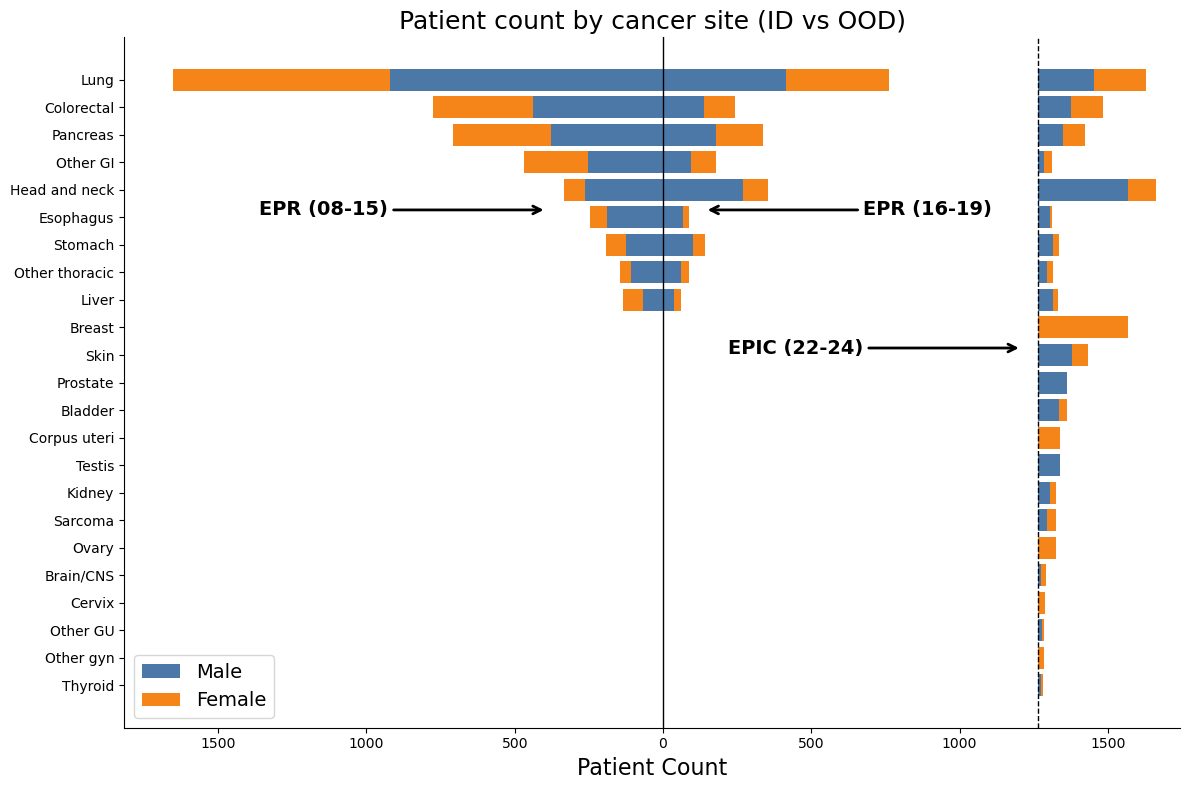

In [34]:
fig, ax = plot_id_ood_cancer_counts(df_idd_processed, df_ood_processed)

In [35]:
save_dir = os.path.join(WORK_DIR, 'gitrepo/2024/OncoTRAIL/paper/pmh_method/results/plots/schema')
fig.savefig(f"{save_dir}/cancer_site.png", dpi=300)